# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [ ]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42) # stratify=y

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.8655,0.8582,0.4874,0.7745,0.5975,0.5220,0.5425,0.3260
lightgbm,Light Gradient Boosting Machine,0.8579,0.8495,0.4935,0.7287,0.5869,0.5051,0.5199,0.4040
gbc,Gradient Boosting Classifier,0.8643,0.8565,0.4614,0.7912,0.5812,0.5073,0.5343,0.0670
xgboost,Extreme Gradient Boosting,0.8507,0.8346,0.4996,0.6895,0.5787,0.4909,0.5007,0.0150
rf,Random Forest Classifier,0.8593,0.8391,0.4649,0.7572,0.5747,0.4964,0.5183,0.0680
ada,Ada Boost Classifier,0.8568,0.8389,0.4735,0.7352,0.5747,0.4937,0.5117,0.0220
et,Extra Trees Classifier,0.8505,0.8336,0.4370,0.7267,0.5454,0.4626,0.4842,0.0470
dt,Decision Tree Classifier,0.7882,0.6880,0.5178,0.4864,0.5012,0.3670,0.3676,0.0090
qda,Quadratic Discriminant Analysis,0.8366,0.8107,0.3189,0.7379,0.4445,0.3661,0.4109,0.0040
lda,Linear Discriminant Analysis,0.8021,0.7562,0.1946,0.5571,0.2877,0.2026,0.2410,0.0040


인코딩 결과(앞에서부터 0, 1, 2)
['Female' 'Male']
['France' 'Germany' 'Spain']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   country           10000 non-null  int64  
 2   gender            10000 non-null  int64  
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   products_number   10000 non-null  int64  
 7   credit_card       10000 non-null  int64  
 8   active_member     10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  churn             10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


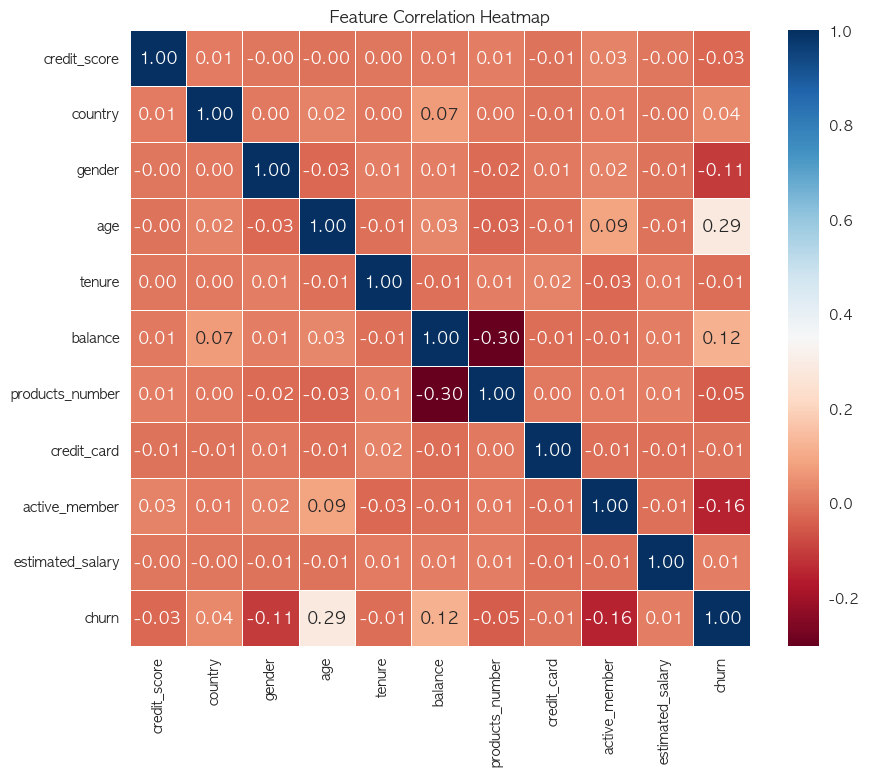

In [ ]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)

# 전처리
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

# df 원본에서 country, gender는 범주형이므로 이를 자동으로 변환하기 위해 인코딩을 실행한다.

print(f"인코딩 결과(앞에서부터 0, 1, 2)")
print(le_gender.classes_)
print(le_country.classes_)
print("")

# 1. 전처리 후 데이터 정보확인
df.info()

# => 전처리 후 정보를 살펴보면 결측치는 없고 범주형 데이터도 변환 완료하였다.

# 2. EDA
import seaborn as sns
# 2-1. 
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Feature Selection 선정 기준
# - 해당 과제의 목표가 이탈 고객을 찾는 것이므로 타겟 변수를 churn(이탈 여부)으로 지정하였고 나머지 변수들은 X로 지정하였다.

# 3. 분할 및 스케일링

# X, y 지정
X = df.drop('churn', axis=1)
y = df['churn']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid) 

위의 히트맵을 통해 타겟 변수로 설정한 churn과 상관관계 상위 4개인 age, active_member, balance, gender를 개별로 살펴봤다.

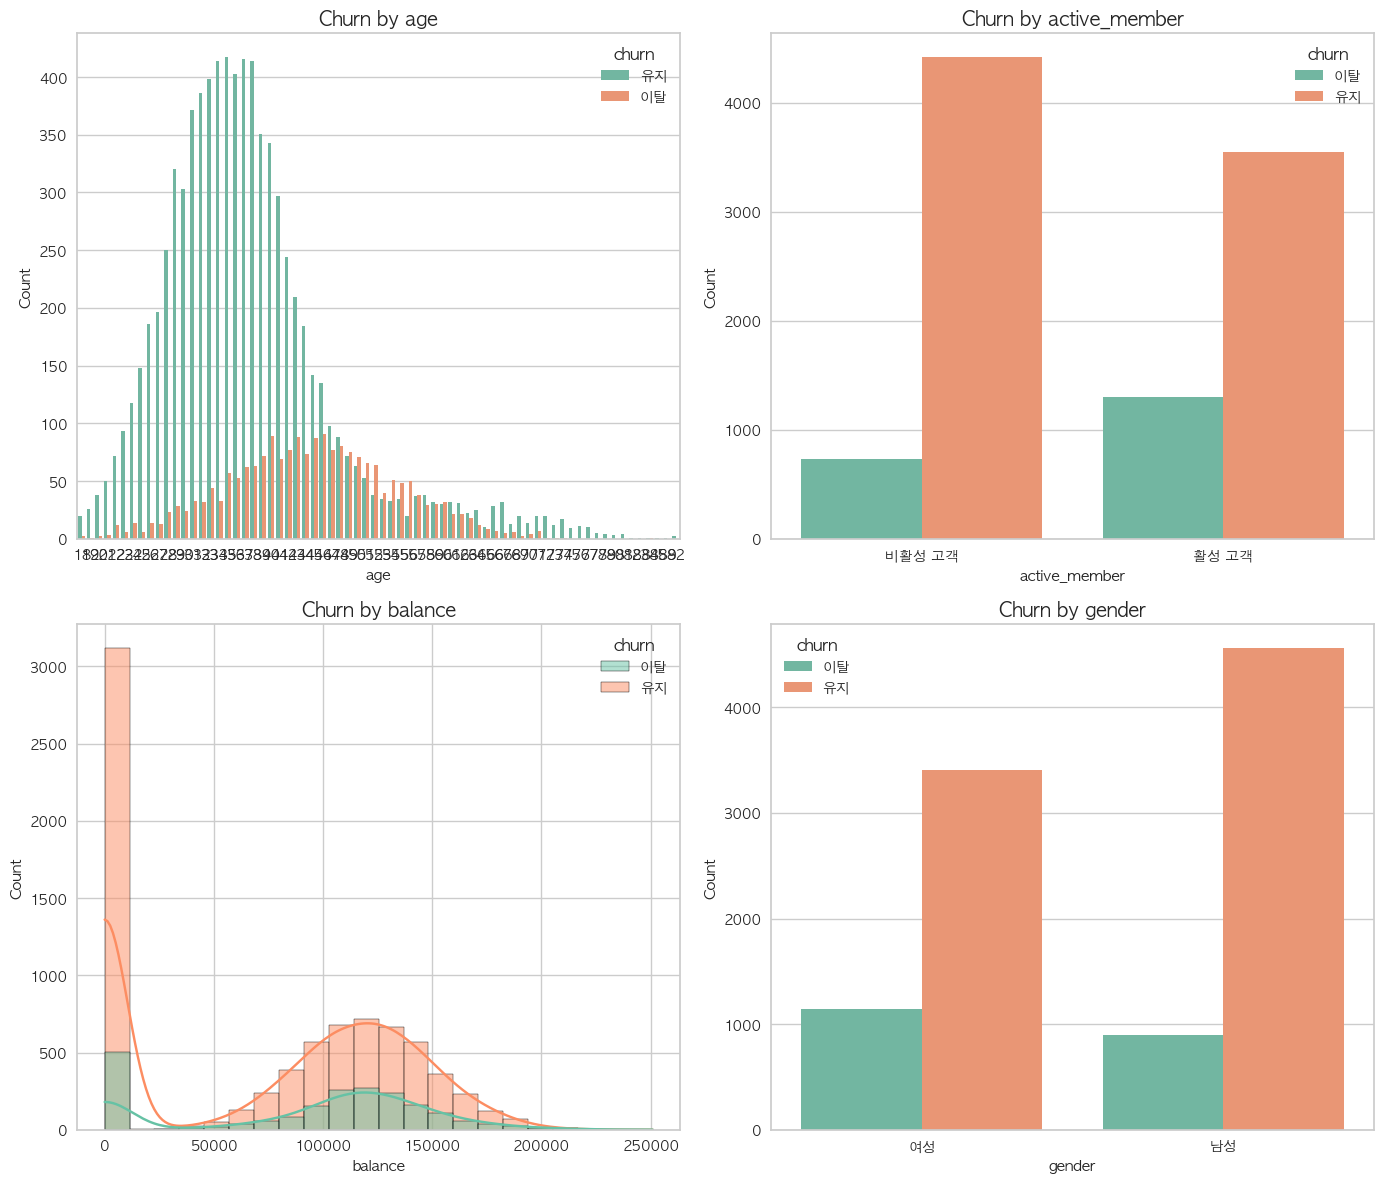

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['active_member'] = df['active_member'].map({0: '활성 고객', 1: '비활성 고객'})
df['gender'] = df['gender'].map({0: '여성', 1: '남성'})
df['churn'] = df['churn'].map({0: '유지', 1: '이탈'})

cols_to_plot = ['age', 'active_member', 'balance', 'gender']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if col == 'balance':
        sns.histplot(data=df, x=col, hue='churn', kde=True, ax=axes[i], palette='Set2')
    else:
        sns.countplot(data=df, x=col, hue='churn', ax=axes[i], palette='Set2')
    
    axes[i].set_title(f'Churn by {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 개별 그래프 해석

- age : 유지고객의 경우 연령대 그래프의 첨도가 왼쪽에 위치하고 있고 이탈고객의 경우 첨도가 오른쪽에 있다. 따라서 유지고객은 연령대가 상대적으로 낮고 이탈고객은 연령대가 상대적으로 높아 이탈고객일수록 연령대가 높아진다는 것을 알 수 있다. -> 중장년층의 이탈고객 다수 분포하는 모습은 중장년층의 높은 투자선호도로 인해 은행을 이탈해 증권으로 옮길 확률이 높다고 예상된다.

- active_member : 비활성 고객은 활성 고객 대비 유지 고객의 비율이 상대적으로 높고 이탈 고객의 비율이 상대적으로 낮다. 따라서 이탈고객 중 활성 고객이 더 많다는 것을 알 수 있다. -> 활성 고객 대상 -> 비활성 고객의 경우 휴면으로 관리가 되어 이탈되지 않아 표시 상 활성 고객의 이탈이 더 많아 보인다고 예상된다.

- balance : 자산이 0에 근접한 경우 이탈고객과 유지고객이 가장 많고 이탈고객과 유지고객 모두 자산이 어느정도 이상이 되면 종모양의 그래프를 그린다. 따라서 이탈고객과 유지고객의 자산 분포는 유사하다고 볼 수 있다. -> 0에 많이 분포하는 그룹은 해당 은행이 주거래 은행이 아닌 고객이 많을 것으로 예상되고 오른쪽 종모양의 그래프의 경우 자산이 동일하다는 가정 하 이탈고객과 유지고객이 특정 비율을 유지하고 있어서 해당 종모양 그래프가 나온다고 예상된다.

- gender : 여성의 경우 남성 대비 유지 고객의 비율이 상대적으로 낮고 이탈 고객의 비율이 상대적으로 높다. 따라서 이탈고객 중 여성이 더 많다는 것을 알 수 있다. -> 여성의 경우 조금 더 정보에 민감하여 조금 더 높은 금리 상품 등 이탈요인을 남성보다 더 많이 접할 가능성이 커서 여성고객의 이탈이 더 많아 보인다고 예산된다.

## ML 선정 기준

- 위 pycaret을 통해 f1_score 상위 4개 모델을 사용하기로 하였다. (상위모델 4개 : catboost, lightgbm, gbc, xgboost)


In [ ]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)

import optuna
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score

# CatBoost 
def objective_cb(trial):
    params = {
        'iterations': trial.suggest_int('n_estimators', 100, 500), 
        'depth': trial.suggest_int('depth', 4, 10),             
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'verbose': False,
        'allow_writing_files': False
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# LightGBM
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 31, 256), 
    }
    model = LGBMClassifier(**params, verbosity=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# GBC 
def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
    }
    model = GradientBoostingClassifier(**params)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# XGBoost 
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
    }
    model = XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective_cb, n_trials=10)

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=10)

study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=10)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=10)

# 최종 모델 정의
cb = CatBoostClassifier(**study_cb.best_params)
lg = LGBMClassifier(**study_lgb.best_params)
gbc = GradientBoostingClassifier(**study_gbc.best_params)
xgb = XGBClassifier(**study_xgb.best_params)

# 모델 학습
cb.fit(X_train, y_train)
lg.fit(X_train, y_train)
gbc.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('CB', cb), ('LGB', lg), ('GBC', gbc), ('XGB', xgb)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

[I 2026-04-09 17:22:49,002] A new study created in memory with name: no-name-b0cb0f45-e139-48cd-b7c6-de4b32640e77
[I 2026-04-09 17:22:49,647] Trial 0 finished with value: 0.6090909090909091 and parameters: {'n_estimators': 454, 'depth': 4, 'learning_rate': 0.07440996912756014}. Best is trial 0 with value: 0.6090909090909091.
[I 2026-04-09 17:22:50,153] Trial 1 finished with value: 0.5837037037037037 and parameters: {'n_estimators': 151, 'depth': 10, 'learning_rate': 0.19716735543880984}. Best is trial 0 with value: 0.6090909090909091.
[I 2026-04-09 17:22:50,237] Trial 2 finished with value: 0.588597842835131 and parameters: {'n_estimators': 132, 'depth': 4, 'learning_rate': 0.23081129241102424}. Best is trial 0 with value: 0.6090909090909091.
[I 2026-04-09 17:22:50,817] Trial 3 finished with value: 0.5617647058823529 and parameters: {'n_estimators': 232, 'depth': 8, 'learning_rate': 0.29816048313607446}. Best is trial 0 with value: 0.6090909090909091.
[I 2026-04-09 17:22:52,313] Trial 

0:	learn: 0.6473754	total: 1.51ms	remaining: 686ms
1:	learn: 0.5993155	total: 3.18ms	remaining: 718ms
2:	learn: 0.5668854	total: 4.42ms	remaining: 665ms
3:	learn: 0.5348040	total: 5.78ms	remaining: 650ms
4:	learn: 0.5110031	total: 7.21ms	remaining: 647ms
5:	learn: 0.4847372	total: 8.42ms	remaining: 629ms
6:	learn: 0.4682992	total: 9.73ms	remaining: 621ms
7:	learn: 0.4524043	total: 11.2ms	remaining: 622ms
8:	learn: 0.4378438	total: 12.6ms	remaining: 623ms
9:	learn: 0.4284900	total: 14.1ms	remaining: 625ms
10:	learn: 0.4201711	total: 15.5ms	remaining: 623ms
11:	learn: 0.4105028	total: 16.8ms	remaining: 619ms
12:	learn: 0.4026216	total: 18.2ms	remaining: 616ms
13:	learn: 0.3972109	total: 19.5ms	remaining: 614ms
14:	learn: 0.3920980	total: 21.1ms	remaining: 618ms
15:	learn: 0.3877895	total: 22.5ms	remaining: 616ms
16:	learn: 0.3841658	total: 23.8ms	remaining: 613ms
17:	learn: 0.3799079	total: 25.1ms	remaining: 609ms
18:	learn: 0.3771062	total: 26.3ms	remaining: 603ms
19:	learn: 0.3734706	t

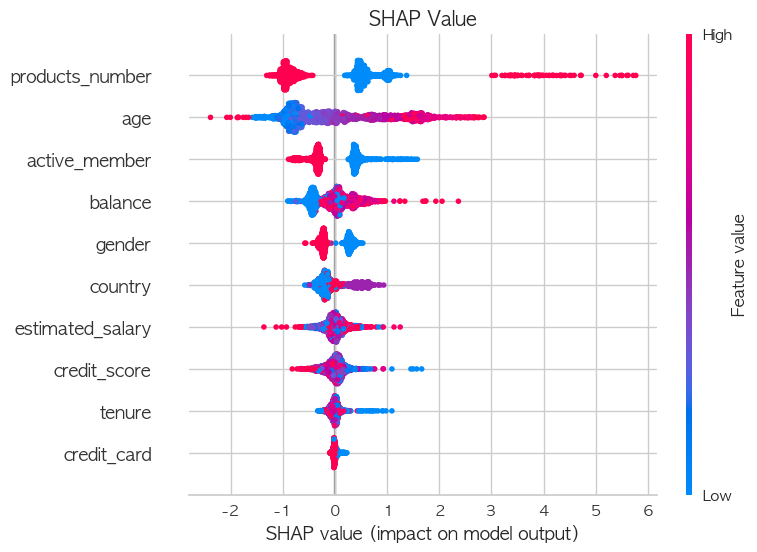

In [ ]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)

# catboost, lightgbm, gbc, xgboost 해당 모델 중 f1 score가 가장 높은 CatBoost 사용
explainer = shap.TreeExplainer(cb)
shap_values = explainer.shap_values(X_valid)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()

## SHAP value 사후분석

- 위에서부터 아래로는 feature의 영향도 순이다.

- products_number : 영향력이 가장 큰 feature인 은행에서 이용 중인 상품 수가 적은 경우 이탈할 확률이 높아지고 상품 수가 많은 경우에는 이탈하지 않을 확률도 있지만 이탈할 확률이 매우 높아질 수 있다.

- age : 나이가 어릴수록 이탈할 확률이 낮아지고 나이가 높아지면 이탈할 확률이 높아진다.

- active_member : 활성 고객 여부가 0(없음)인 경우 이탈할 확률이 높아지고 활성 고객 여부가 1(있음)인 경우 이탈할 확률이 낮아진다. 

- balance : 잔고가 적은 경우 이탈할 확률이 낮아지고 잔고가 많은 경우 영향이 없거나 이탈할 확률이 높아진다.

- gender : 성별이 0(여자)인 경우 이탈할 확률이 높아지고 성별이 1(남자)인 경우 이탈할 확률이 낮아진다.

- country : 국가가 0(프랑스)인 경우 이탈할 확률이 낮아지고 국가가 1(독일)인 경우 이탈할 확률이 높아지고 국가가 2(스페인)인 경우 골고루 분포해 영향이 적다

- estimated_salary : 추정 연봉이 적을때에는 0에 가깝게 분포해 영향이 적지만 많아질수록 이탈할 확률이 낮아지거나 높아진다.

- credit_score : 신용 점수의 경우 0에 가깝게 분포해 영향이 적지만 점수가 낮을수록 이탈할 확률이 높아지고 점수가 높을수록 이탈할 확률이 낮아진다.

- tenure : 은행 이용 기간의 경우 0에 가깝게 분포해 영향이 적지만 기간이 낮을수록 이탈할 확률이 높아지고 기간이 높을수록 이탈할 확률이 낮아진다.

- credit_card : 신용카드 보유 여부의 경우 0에 가깝게 분포해 영향이 적다.

In [ ]:
# 4개 모델을 Stacking (전방모델, 후방모델 아무거나) F1 스코어, accuracy_score

from sklearn.metrics import accuracy_score

# 전방 모델 리스트
est_model_list = [
                      ('CB', cb), 
                      ('LGB', lg), 
                      ('GBC', gbc), 
                      ('XGB', xgb)
                  ]

# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))
print("Stacking accuracy:", accuracy_score(y_valid, pred))

0:	learn: 0.6473754	total: 2.5ms	remaining: 1.13s
1:	learn: 0.5993155	total: 3.99ms	remaining: 902ms
2:	learn: 0.5668854	total: 5.37ms	remaining: 808ms
3:	learn: 0.5348040	total: 6.7ms	remaining: 754ms
4:	learn: 0.5110031	total: 7.98ms	remaining: 717ms
5:	learn: 0.4847372	total: 9.24ms	remaining: 690ms
6:	learn: 0.4682992	total: 10.6ms	remaining: 679ms
7:	learn: 0.4524043	total: 12ms	remaining: 671ms
8:	learn: 0.4378438	total: 13.4ms	remaining: 660ms
9:	learn: 0.4284900	total: 14.6ms	remaining: 648ms
10:	learn: 0.4201711	total: 15.9ms	remaining: 641ms
11:	learn: 0.4105028	total: 17.4ms	remaining: 640ms
12:	learn: 0.4026216	total: 18.8ms	remaining: 639ms
13:	learn: 0.3972109	total: 20.3ms	remaining: 638ms
14:	learn: 0.3920980	total: 21.5ms	remaining: 629ms
15:	learn: 0.3877895	total: 22.8ms	remaining: 623ms
16:	learn: 0.3841658	total: 24.3ms	remaining: 624ms
17:	learn: 0.3799079	total: 25.6ms	remaining: 621ms
18:	learn: 0.3771062	total: 27.3ms	remaining: 625ms
19:	learn: 0.3734706	total

## validation score

- 스테킹을 위해 앞의 전방모델은 catboost, lightgbm, gbc, xgboost을 사용하였고 후방모델에 복잡한 모델을 사용하게 되면 과적합이 될 위험이 크기 때문에 로지스틱회귀를 사용하였다.

- 스테킹 결과 f1 score는 0.6111951588502269 / accuracy score는 0.8715가 나와 정확도는 높지만 f1 score는 낮게 나왔다.